<a href="https://colab.research.google.com/github/PhcPh4m/Bank-Loan-Default-Prediction/blob/main/notebook/Bank_Loan_Classification_Large_Scale_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- 1. Cấu hình hệ thống & Môi trường (System & Python Requirements) ---
import os

# Định nghĩa các biến đường dẫn
SPARK_VER = "3.1.2"
SPARK_DIR = f"spark-{SPARK_VER}-bin-hadoop3.2"
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = f"/content/{SPARK_DIR}"
os.environ["HADOOP_CONF_DIR"] = os.path.join(os.environ["SPARK_HOME"], "conf", "hadoop")

def setup_environment():
    # Kiểm tra nếu chưa cài đặt thì mới thực hiện
    if not os.path.exists(SPARK_DIR):
        print("Đang thiết lập môi trường...")

        # Cài đặt Java và Spark
        !apt-get install openjdk-8-jdk-headless -qq > /dev/null
        !wget -q https://archive.apache.org/dist/spark/spark-{SPARK_VER}/{SPARK_DIR}.tgz
        !tar xf {SPARK_DIR}.tgz

        # Tạo cấu hình Hadoop core-site.xml giả lập HDFS
        conf_path = os.environ["HADOOP_CONF_DIR"]
        os.makedirs(conf_path, exist_ok=True)
        with open(os.path.join(conf_path, "core-site.xml"), "w") as f:
            f.write("""<?xml version="1.0" encoding="UTF-8"?>
<configuration>
    <property>
        <name>fs.defaultFS</name>
        <value>file:///</value>
    </property>
</configuration>""")

        # Cài đặt thư viện
        !pip install -q findspark pyspark=={SPARK_VER} matplotlib seaborn pandas numpy scikit-learn gdown > /dev/null 2>&1
        return True
    return False

# Chạy thiết lập
is_new_install = setup_environment()

# Khởi tạo Spark
import findspark
findspark.init()

from pyspark.sql import SparkSession
spark = SparkSession.builder.master("local[*]").appName("BankLoanProject").getOrCreate()

# Thông báo duy nhất ra màn hình
if is_new_install:
    print("Hệ thống đã được cài đặt và sẵn sàng!")
else:
    print(" Môi trường đã sẵn sàng.")

# --- Import các thư viện cần thiết (Chạy ngầm) ---
from pyspark.sql import functions as F
from pyspark.sql.types import *
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

 Môi trường đã sẵn sàng.


# --- DATA SOURCE CREDENTIALS ---
# Original Source: Lending Club Dataset (Accepted Loans 2007-2018Q4)
# URL: https://www.kaggle.com/datasets/wordsforthewise/lending-club
# Note: To ensure "One-Click" execution, the raw CSV has been mirrored
# -------------------------------

In [2]:
import os

# 1. Cấu hình thông tin
FILE_ID = '1JqzOzmA6VLPYb_HST75FJR21qYOdhEei'
local_path = '/content/accepted_2007_to_2018Q4.csv'
hdfs_path = '/user/phucpham/data/loan_data.csv'

# 2. Tải dữ liệu từ Google Drive
if not os.path.exists(local_path):
    print("Đang tải bộ dữ liệu...")
    !pip install -q gdown > /dev/null 2>&1
    import gdown
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', local_path, quiet=True)

# 3. Nạp dữ liệu vào HDFS giả lập
if os.path.exists(local_path):

    os.system(f"$SPARK_HOME/bin/spark-class org.apache.hadoop.fs.FsShell -mkdir -p /user/phucpham/data/ > /dev/null 2>&1")

    # Đẩy file vào HDFS:
    # -f để ghi đè nếu đã tồn tại
    # > /dev/null 2>&1 để chặn đứng các dòng log4j đỏ của Hadoop
    put_cmd = f"$SPARK_HOME/bin/spark-class org.apache.hadoop.fs.FsShell -put -f '{local_path}' '{hdfs_path}' > /dev/null 2>&1"

    status = os.system(put_cmd)

    if status == 0:
        print("Dữ liệu từ Bank-Loan-Prediction-data đã được nạp vào HDFS thành công!")
    else:
        print("Lỗi: Hệ thống không thể đẩy dữ liệu vào HDFS nội bộ.")
else:
    print(f"Lỗi: Không thể tải tệp từ Google Drive. Vui lòng kiểm tra quyền chia sẻ của file.")

Dữ liệu từ Bank-Loan-Prediction-data đã được nạp vào HDFS thành công!


In [3]:
# Khởi động NameNode và DataNode
!$HADOOP_HOME/sbin/start-dfs.sh

# Kiểm tra xem các tiến trình đã chạy chưa
!jps

/bin/bash: line 1: /sbin/start-dfs.sh: No such file or directory
43649 SparkSubmit
44022 Jps


In [4]:
!$HADOOP_HOME/bin/hdfs dfs -ls /user/phucpham/data/

/bin/bash: line 1: /bin/hdfs: No such file or directory


In [5]:
# 1. Cấu hình đường dẫn Chuẩn hóa
hdfs_path = "/user/phucpham/data/loan_data.csv"

# 2. Tối ưu hóa việc đọc dữ liệu
print("Đang nạp dữ liệu từ HDFS...")

try:
    df = spark.read.csv(hdfs_path, header=True, inferSchema=False)

    count = df.count()
    print(f"Thành công! Hệ thống đã nhận diện: {count:,} bản ghi.")

    # Hiển thị cấu trúc dữ liệu gọn gàng
    df.printSchema()

except Exception as e:
    print("Lỗi truy cập HDFS. Đang kiểm tra lại file system...")
    !$SPARK_HOME/bin/spark-class org.apache.hadoop.fs.FsShell -ls /user/phucpham/data/

Đang nạp dữ liệu từ HDFS...
Thành công! Hệ thống đã nhận diện: 2,260,701 bản ghi.
root
 |-- id: string (nullable = true)
 |-- member_id: string (nullable = true)
 |-- loan_amnt: string (nullable = true)
 |-- funded_amnt: string (nullable = true)
 |-- funded_amnt_inv: string (nullable = true)
 |-- term: string (nullable = true)
 |-- int_rate: string (nullable = true)
 |-- installment: string (nullable = true)
 |-- grade: string (nullable = true)
 |-- sub_grade: string (nullable = true)
 |-- emp_title: string (nullable = true)
 |-- emp_length: string (nullable = true)
 |-- home_ownership: string (nullable = true)
 |-- annual_inc: string (nullable = true)
 |-- verification_status: string (nullable = true)
 |-- issue_d: string (nullable = true)
 |-- loan_status: string (nullable = true)
 |-- pymnt_plan: string (nullable = true)
 |-- url: string (nullable = true)
 |-- desc: string (nullable = true)
 |-- purpose: string (nullable = true)
 |-- title: string (nullable = true)
 |-- zip_code: st

In [6]:
from pyspark.sql.functions import col

# Chọn ra các cột quan trọng nhất giống như trong bản KNN cũ
df_final = df.select(
    col("loan_status"),
    col("loan_amnt").cast("double"),
    col("int_rate").cast("double"),
    col("installment").cast("double"),
    col("grade"),
    col("term"),
    col("annual_inc").cast("double"),
    col("dti").cast("double"),
    col("fico_range_low").cast("double"),
    col("fico_range_high").cast("double")
)

# Kiểm tra lại xem đã về dạng số (double) chưa
df_final.printSchema()

# Xem thử thống kê mô tả (giống df.describe() của Pandas)
df_final.describe(["annual_inc", "loan_amnt"]).show()

root
 |-- loan_status: string (nullable = true)
 |-- loan_amnt: double (nullable = true)
 |-- int_rate: double (nullable = true)
 |-- installment: double (nullable = true)
 |-- grade: string (nullable = true)
 |-- term: string (nullable = true)
 |-- annual_inc: double (nullable = true)
 |-- dti: double (nullable = true)
 |-- fico_range_low: double (nullable = true)
 |-- fico_range_high: double (nullable = true)

+-------+------------------+------------------+
|summary|        annual_inc|         loan_amnt|
+-------+------------------+------------------+
|  count|           2260663|           2260668|
|   mean|  77992.4463776422|15046.931227849467|
| stddev|112696.22136091373| 9190.245488232755|
|    min|               0.0|             500.0|
|    max|             1.1E8|           40000.0|
+-------+------------------+------------------+



In [7]:
# Loại bỏ các dòng có giá trị Null ở các cột quan trọng
df_clean = df_final.na.drop(subset=["loan_status", "annual_inc", "int_rate", "dti"])

print(f"Số lượng dòng sau khi làm sạch: {df_clean.count():,}")

Số lượng dòng sau khi làm sạch: 2,258,697


In [8]:
from pyspark.ml.feature import StringIndexer
from pyspark.sql.functions import col

# 1. Lọc dữ liệu nợ tốt và nợ xấu
df_binary_target = df_clean.filter(
    (col("loan_status") == "Fully Paid") | (col("loan_status") == "Charged Off")
)

# 2. Tách riêng 2 nhóm để cân bằng
df_good = df_binary_target.filter(col("loan_status") == "Fully Paid")
df_bad = df_binary_target.filter(col("loan_status") == "Charged Off")

# 3. Undersampling: Lấy số lượng nợ tốt bằng đúng số lượng nợ xấu
count_bad = df_bad.count()
count_good = df_good.count()
ratio = count_bad / count_good

# Lấy mẫu ngẫu nhiên nhóm nợ tốt với tỷ lệ tương ứng
df_good_balanced = df_good.sample(withReplacement=False, fraction=ratio, seed=42)

# Gộp lại thành tập dữ liệu 50/50
df_balanced = df_bad.unionAll(df_good_balanced)

# 4. Áp dụng StringIndexer trên tập đã cân bằng
grade_indexer = StringIndexer(inputCol="grade", outputCol="grade_idx")
label_indexer = StringIndexer(inputCol="loan_status", outputCol="label")

df_indexed = grade_indexer.fit(df_balanced).transform(df_balanced)
df_indexed = label_indexer.fit(df_indexed).transform(df_indexed)

# Kiểm tra lại tỷ lệ
print("Tỷ lệ nhãn sau khi cân bằng (Phải xấp xỉ 50/50):")
df_indexed.groupBy("label").count().show()

Tỷ lệ nhãn sau khi cân bằng (Phải xấp xỉ 50/50):
+-----+------+
|label| count|
+-----+------+
|  0.0|269151|
|  1.0|268453|
+-----+------+



In [9]:
from pyspark.ml.feature import VectorAssembler

# Danh sách các cột sẽ dùng để dự báo
# Đã loại bỏ 'installment' vì cột này không tồn tại trong df_indexed
feature_cols = [
    "loan_amnt", "int_rate",
    "annual_inc", "dti", "fico_range_low", "grade_idx"
]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Tạo dataset cho model
final_data = assembler.transform(df_indexed).select("features", "label")

final_data.show(5)

+--------------------+-----+
|            features|label|
+--------------------+-----+
|[18000.0,19.48,15...|  1.0|
|[4225.0,14.85,350...|  1.0|
|[16000.0,12.88,65...|  1.0|
|[24250.0,24.24,75...|  1.0|
|[25000.0,13.99,79...|  1.0|
+--------------------+-----+
only showing top 5 rows



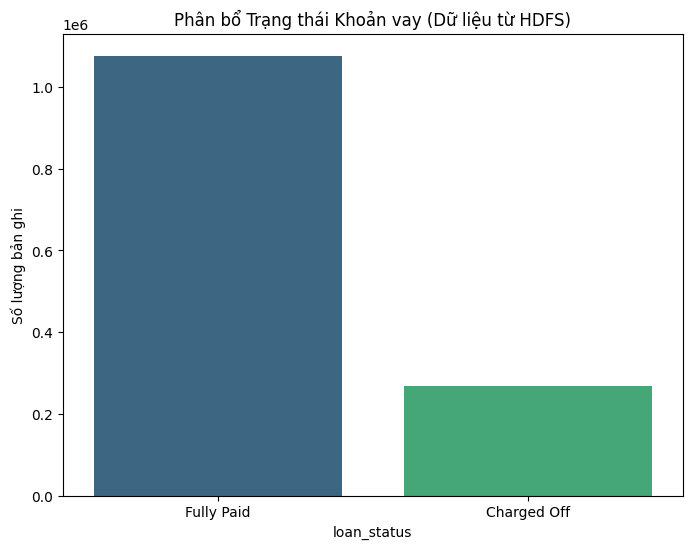

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dùng Spark gom nhóm và đếm
target_dist = df_binary_target.groupBy("loan_status").count().toPandas()

plt.figure(figsize=(8, 6))
sns.barplot(x="loan_status", y="count", data=target_dist, palette="viridis", hue="loan_status", legend=False)
plt.title("Phân bổ Trạng thái Khoản vay (Dữ liệu từ HDFS)")
plt.ylabel("Số lượng bản ghi")
plt.show()

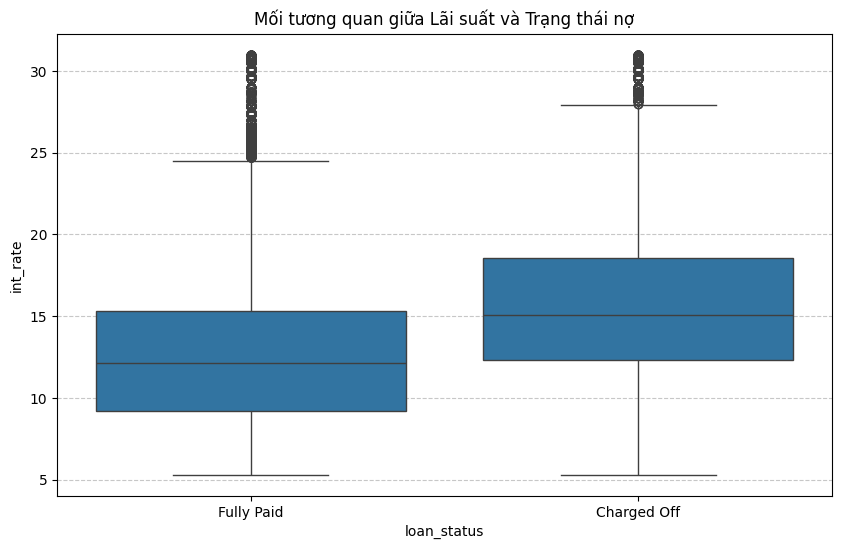

In [11]:
# Lấy mẫu (Sample) 10% để vẽ biểu đồ
sample_df = df_binary_target.select("loan_status", "int_rate").sample(False, 0.1, seed=42).toPandas()

plt.figure(figsize=(10, 6))
sns.boxplot(x="loan_status", y="int_rate", data=sample_df)
plt.title("Mối tương quan giữa Lãi suất và Trạng thái nợ")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

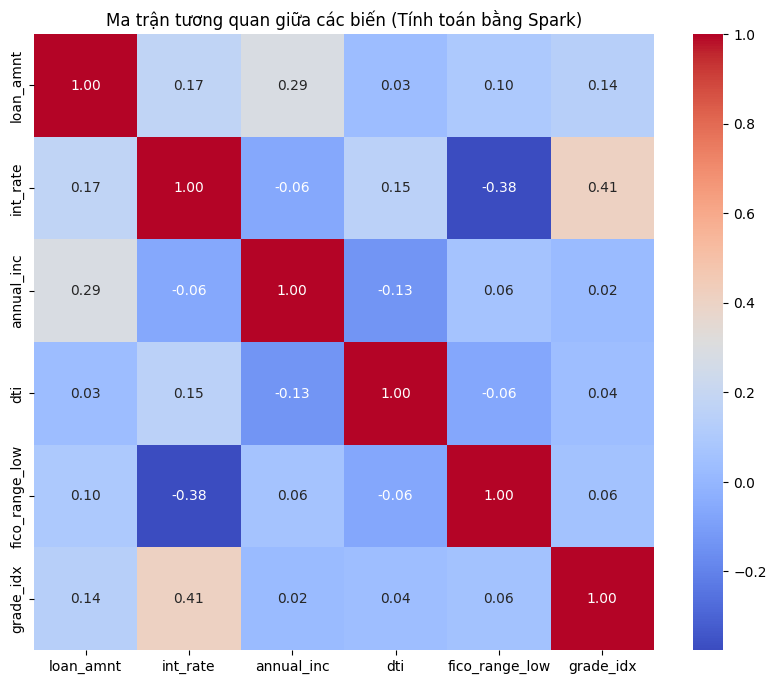

In [12]:
from pyspark.ml.stat import Correlation

# Define feature_list here so it's available for plotting
feature_list = [
    "loan_amnt", "int_rate",
    "annual_inc", "dti", "fico_range_low", "grade_idx"
]

# Tính toán ma trận tương quan trên Spark
vector_col = "corr_features"
assembler_corr = VectorAssembler(inputCols=feature_list, outputCol=vector_col)
df_vector = assembler_corr.transform(df_indexed).select(vector_col)

matrix = Correlation.corr(df_vector, vector_col).collect()[0][0]
cor_np = matrix.toArray()

# Vẽ bằng Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cor_np, xticklabels=feature_list, yticklabels=feature_list, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các biến (Tính toán bằng Spark)")
plt.show()

In [13]:
# Chia dữ liệu theo tỉ lệ 8:2
train_data, test_data = final_data.randomSplit([0.8, 0.2], seed=42)

print(f" Dữ liệu huấn luyện: {train_data.count():,}")
print(f" Dữ liệu kiểm thử: {test_data.count():,}")

 Dữ liệu huấn luyện: 430,054
 Dữ liệu kiểm thử: 107,550


In [14]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    seed=42,
    maxDepth=5,             # Giữ độ sâu vừa phải để tránh bùng nổ tính toán
    subsamplingRate=0.7,    # Mỗi cây dùng 70% dữ liệu
    maxMemoryInMB=1024,     # Tăng RAM xử lý cho các node
    cacheNodeIds=True,      # Cache các node để các cây sau dùng lại kết quả
    checkpointInterval=10   # Cứ 10 cây thì lưu checkpoint một lần để giải phóng bộ nhớ
)

# Bắt đầu huấn luyện
rf_model = rf.fit(train_data)

print("Huấn luyện Random Forest thành công!")

Huấn luyện Random Forest thành công!


In [15]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Dự báo trên 20% dữ liệu kiểm thử (test_data)
predictions = rf_model.transform(test_data)

# Tính Accuracy
evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
accuracy_rf = evaluator_acc.evaluate(predictions)

# Tính AUC (Area Under ROC)
evaluator_auc = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="probability", metricName="areaUnderROC")
auc_rf = evaluator_auc.evaluate(predictions)

# --- BẢNG SO SÁNH (Giả định thông số KNN của bạn khoảng 75-80%) ---
print("\n" + "="*30)
print("KẾT QUẢ SO SÁNH MÔ HÌNH")
print("="*30)
print(f"1. Spark Random Forest Accuracy: {accuracy_rf*100:.2f}%")
print(f"2. Spark Random Forest AUC:      {auc_rf:.4f}")


KẾT QUẢ SO SÁNH MÔ HÌNH
1. Spark Random Forest Accuracy: 64.05%
2. Spark Random Forest AUC:      0.6952


In [16]:
# Lấy độ quan trọng của các biến
import pandas as pd

importances = rf_model.featureImportances.toArray()
feature_list = ["loan_amnt", "int_rate", "annual_inc", "dti", "fico_range_low", "grade_idx"]

# Tạo bảng để dễ quan sát
fi_df = pd.DataFrame({'Feature': feature_list, 'Importance': importances})
print("\nĐộ quan trọng của các biến:")
print(fi_df.sort_values(by='Importance', ascending=False))


Độ quan trọng của các biến:
          Feature  Importance
1        int_rate    0.683169
5       grade_idx    0.229456
4  fico_range_low    0.041906
3             dti    0.024154
0       loan_amnt    0.018419
2      annual_inc    0.002896


/tmp/ipykernel_43626/3599351692.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette='viridis')


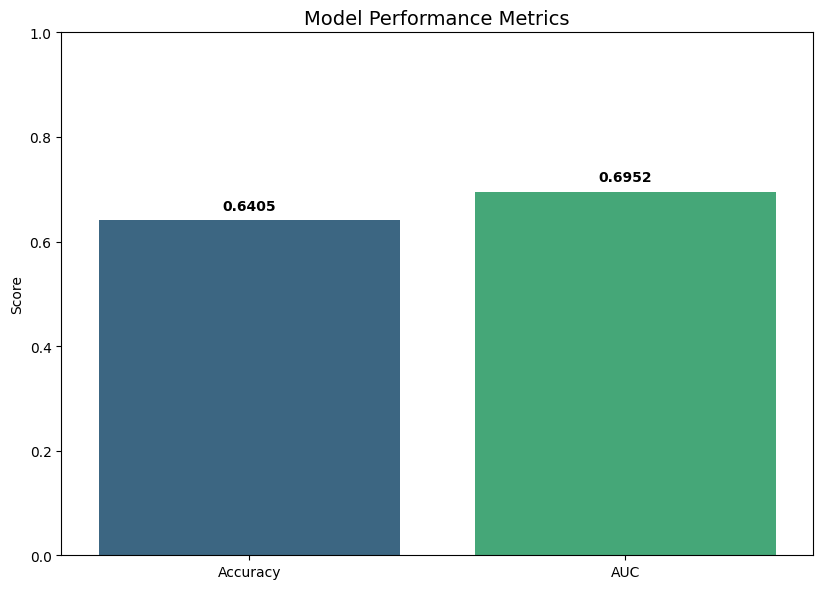

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Vẽ biểu đồ
plt.figure(figsize=(16, 6))

# So sánh Accuracy vs AUC
plt.subplot(1, 2, 2)
metrics = ['Accuracy', 'AUC']
values = [accuracy_rf, auc_rf]
sns.barplot(x=metrics, y=values, palette='viridis')
plt.ylim(0, 1.0)
plt.title('Model Performance Metrics', fontsize=14)
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.ylabel('Score')

plt.tight_layout()
plt.show()


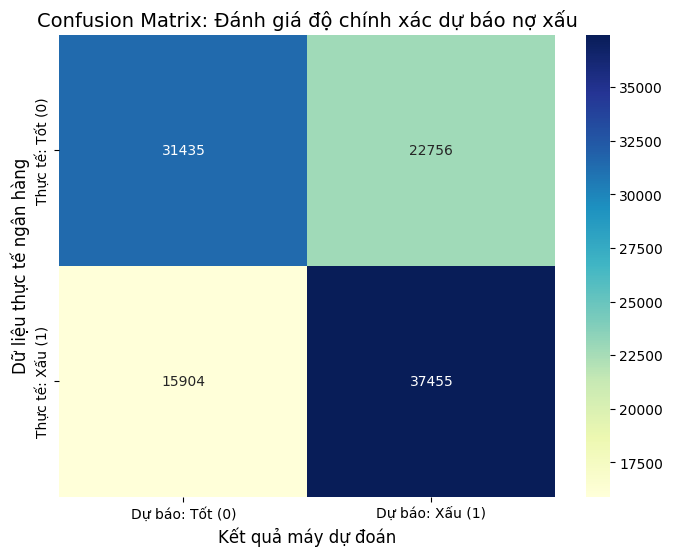

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Chuyển kết quả từ Spark sang Pandas (chỉ lấy 2 cột label và prediction)
y_true = predictions.select("label").toPandas()
y_pred = predictions.select("prediction").toPandas()

# 2. Tạo ma trận nhầm lẫn
cm = confusion_matrix(y_true, y_pred)

# 3. Vẽ biểu đồ Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Dự báo: Tốt (0)', 'Dự báo: Xấu (1)'],
            yticklabels=['Thực tế: Tốt (0)', 'Thực tế: Xấu (1)'])

plt.title('Confusion Matrix: Đánh giá độ chính xác dự báo nợ xấu', fontsize=14)
plt.xlabel('Kết quả máy dự đoán', fontsize=12)
plt.ylabel('Dữ liệu thực tế ngân hàng', fontsize=12)
plt.show()

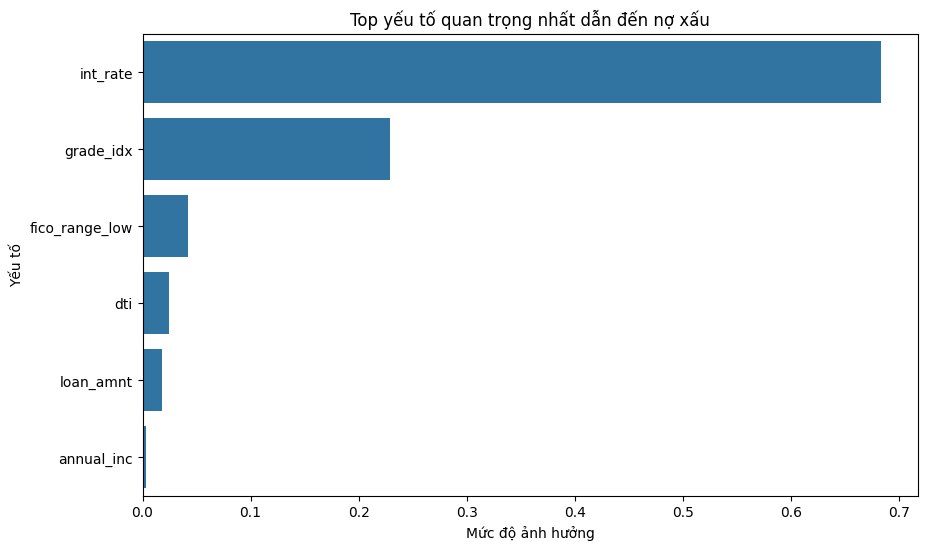

In [19]:
# Lấy độ quan trọng từ model đã huấn luyện
importances = rf_model.featureImportances
features = feature_list

import pandas as pd
feat_imp_df = pd.DataFrame(list(zip(features, importances.toArray())),
                           columns=['Yếu tố', 'Mức độ ảnh hưởng']).sort_values(by='Mức độ ảnh hưởng', ascending=False)

# Vẽ biểu đồ cột ngang
plt.figure(figsize=(10, 6))
sns.barplot(x='Mức độ ảnh hưởng', y='Yếu tố', data=feat_imp_df.head(10))
plt.title("Top yếu tố quan trọng nhất dẫn đến nợ xấu")
plt.show()

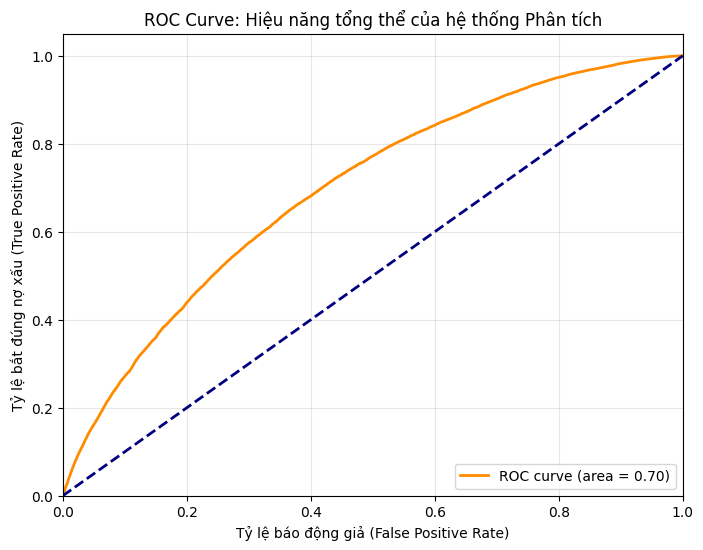

Diện tích dưới đường cong (AUC): 0.6952


In [20]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

# 1. Lấy xác suất và nhãn thực tế từ Spark DataFrame
results_pandas = predictions.select("probability", "label").toPandas()

# 2. Extract probability of the positive class (class 1) in Pandas
results_pandas['probability_positive'] = results_pandas['probability'].apply(
    lambda vec: float(vec[1]) if vec is not None and len(vec) > 1 else None
)

# Drop rows where probability_positive could not be extracted
results_pandas.dropna(subset=["probability_positive", "label"], inplace=True)

if not results_pandas.empty:
    # 3. Tính toán ROC curve và AUC bằng sklearn
    fpr, tpr, thresholds = roc_curve(results_pandas["label"], results_pandas["probability_positive"])
    roc_auc = auc(fpr, tpr)

    # 4. Vẽ biểu đồ ROC
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tỷ lệ báo động giả (False Positive Rate)')
    plt.ylabel('Tỷ lệ bắt đúng nợ xấu (True Positive Rate)')
    plt.title('ROC Curve: Hiệu năng tổng thể của hệ thống Phân tích')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    print(f"Diện tích dưới đường cong (AUC): {roc_auc:.4f}")
else:
    print("No valid data to plot ROC curve after processing.")